## **PYTHON PROJECT #3**

Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Data

In [54]:
from google.colab import files
uploaded = files.upload()

Saving NYPD_Arrest_Data_(Year_to_Date)_20260402.csv to NYPD_Arrest_Data_(Year_to_Date)_20260402 (1).csv


In [55]:
df=pd.read_csv('NYPD_Arrest_Data_(Year_to_Date)_20260402.csv')

I'm using the methods df.describe(), df.head(), df.columns and df.info() to see the data

In [56]:
df.describe()

,ARREST_KEY,PD_CD,KY_CD,ARREST_PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,2.789530e+05,278953.000000,278930.000000,278953.000000,278953.000000,2.789530e+05,278953.000000,278953.000000,278953.000000
mean,3.085697e+08,443.764512,258.919467,63.047255,0.932132,1.005315e+06,207515.629314,40.736243,-73.923782
std,5.664370e+06,274.632619,148.433045,34.798913,6.820188,2.235094e+04,29840.507845,0.081812,0.076414
min,2.987043e+08,12.000000,101.000000,1.000000,0.000000,-7.400000e+01,40.000000,40.500390,-74.252488
25%,3.038432e+08,157.000000,117.000000,40.000000,0.000000,9.906010e+05,184932.000000,40.674210,-73.977117
50%,3.086091e+08,439.000000,341.000000,62.000000,0.000000,1.005028e+06,206168.000000,40.732551,-73.924942
75%,3.135027e+08,724.000000,344.000000,100.000000,0.000000,1.017273e+06,235780.000000,40.813808,-73.880601
max,3.182749e+08,997.000000,995.000000,123.000000,97.000000,1.067185e+06,271597.000000,40.912111,-73.700719


In [57]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [58]:
df.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

Cleaning Data

In [60]:
null_values = ["?", "None", "NONE", "null", "NULL", "", "NaN", "nan", "(null)"]

df = df.replace(null_values, np.nan)

I'm using df.isna() that will check how many times I have np.nan (the new value that I used to replace the nulls). I'm using sum() to sum all the values and Im sorting them to see the columns with the most missing values.

In [61]:
df.isna().sum().sort_values(ascending=False)

,0
PERP_SEX,147237
AGE_GROUP,147237
LAW_CAT_CD,1474
OFNS_DESC,23
KY_CD,23
PD_DESC,23
ARREST_KEY,0
PD_CD,0
ARREST_DATE,0
LAW_CODE,0


The columns with missing data are LAW_CAT_CD (level of offense, 1474 values) and KY_CD	(internal classification code, 23 values). I won't use those columns anyways.

In [62]:
df_clean = df.dropna(subset=["PERP_SEX"])

I want to know how many arrest per borough, which borough has the highest number of arrests, and which specific precinct should be avoided overall.

Using df.nunique() to see the total of arrests made.

In [63]:
df.nunique()

,0
ARREST_KEY,278953
ARREST_DATE,365
PD_CD,273
PD_DESC,261
KY_CD,73
OFNS_DESC,62
LAW_CODE,1148
LAW_CAT_CD,5
ARREST_BORO,5
ARREST_PRECINCT,78


Arrests by borough

In [64]:
arrest_by_borough = df.groupby('ARREST_BORO').count()['ARREST_KEY'].sort_values(ascending=False)
print(arrest_by_borough)

ARREST_BORO
K    79882
M    66448
B    62833
Q    58083
S    11707
Name: ARREST_KEY, dtype: int64


The results show that the borough with the most arrests is Brooklyn, and the borough with the lower number of arrests is Staten Island. However, when analyzing this type of data, we should consider the population as well. But for the purpose of this exercise, we will ignore that parameter.

Worst Precinct:

In [65]:
worst_precinct = df.groupby('ARREST_PRECINCT').count()['ARREST_KEY'].sort_values(ascending=False)
print(worst_precinct)

ARREST_PRECINCT
14     10364
40      9244
75      9039
44      7863
103     7803
       ...  
17      1214
100     1172
123      974
111      949
22       109
Name: ARREST_KEY, Length: 78, dtype: int64


The precinct with the most arrest is Precinct 14 with 10,364 arrests.

In [66]:
worst_precinct_num = worst_precinct.idxmax()
print(worst_precinct_num)

14


In [67]:
worst_precinct_borough = df[df['ARREST_PRECINCT'] == worst_precinct_num]['ARREST_BORO'].iloc[0]
print(worst_precinct_borough)

M


Even though the borough with the most arrests is Brooklyn, the precinct with more arrests is located in Manhattan.

Visuals

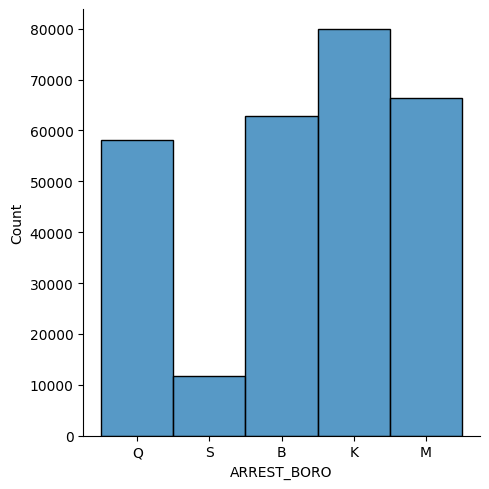

In [68]:
sns.displot(df['ARREST_BORO'])
plt.show()

This visual confirms the values resulting from the "groupby":

The results indicate that Brooklyn has the highest number of arrests, while Staten Island has the lowest.

<Axes: xlabel='ARREST_BORO', ylabel='count'>

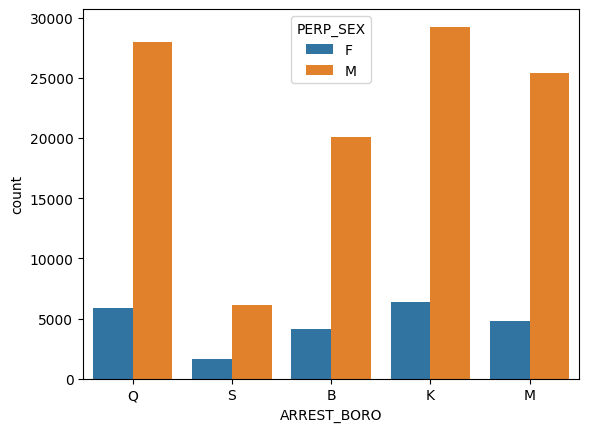

In [70]:
sns.countplot(
    data=df,
    x='ARREST_BORO',hue='PERP_SEX'
)

This visual shows that men is the sex most arrested in all boroughs.

**CONCLUSION**

Brooklyn has the highest number of arrests overall, while Staten Island has the fewest. However, the busiest spot in the city is actually Precinct 14 in Manhattan, which had 10,364 arrests. This shows that even though Brooklyn leads as a borough, the most active single area is in Manhattan. Additionally, the data indicates that men are the most arrested sex in all five boroughs.